In [11]:
from cylinder_generator import generate_cylinders
from camera_model import compute_camera_pair, compute_projections, transform_scene_to_cam1
from render import render_camera_image
from vision import build_vision_matrix

import numpy as np
import matplotlib.pyplot as plt

In [12]:
# dataset-parametrar
NUM_SCENES = 20
MIN_PAIRS = 3
MAX_PAIRS = 8

# cylinders
NUM_CYL = 12
CYL_XMIN = -8
CYL_XMAX = 8
CYL_YMIN = -6
CYL_YMAX = 6
R_MIN = 0.25
R_MAX = 0.8

# rendering
FOV_U = 1.0
FOV_V = 1.0
IMAGE_SIZE = (128, 128)

# camera
CAMERA_DISTANCE = 1.0   # 🔥 HÄR styr du baseline
PAD = 0.5              # mindre slump runt scenen
JITTER = 20            # mindre riktningjitter

USE_NORMALIZED = True   # om du vill köra cam1-frame eller world-frame

# vision matrix
NUM_BINS = 32

In [13]:
dataset = []

for scene_idx in range(NUM_SCENES):

    # -----------------------
    # Generera scen
    # -----------------------
    cylinders, bounds = generate_cylinders(num=NUM_CYL,
    xmin=CYL_XMIN, xmax=CYL_XMAX,
    ymin=CYL_YMIN, ymax=CYL_YMAX,
    r_min=R_MIN, r_max=R_MAX,
    h=50,)

    # färger (bara för rendering/debug)
    cmap = plt.get_cmap("tab10")
    colors = {i: cmap(i) for i in range(len(cylinders))}

    # slumpa antal kamerapar
    num_pairs = np.random.randint(MIN_PAIRS, MAX_PAIRS + 1)

    scene_data = {
        "cylinders": cylinders,
        "pairs": []
    }

    for pair_idx in range(num_pairs):

        # -----------------------
        # Kameror
        # -----------------------
        cam1, cam2 = compute_camera_pair(
            cylinders,
            bounds,
            camera_distance=CAMERA_DISTANCE, angle_jitter_deg=JITTER, pad=PAD
        )

        if USE_NORMALIZED:
            cam1, cam2, cylinders = transform_scene_to_cam1(cam1, cam2, cylinders)

        # -----------------------
        # Projektion
        # -----------------------
        proj1, proj2 = compute_projections(cam1, cam2, cylinders)
        if len(proj1) == 0 or len(proj2) == 0:
            continue

        # -----------------------
        # Rendera bilder
        # -----------------------
        img1 = render_camera_image(
            proj1,
            colors,
            image_size=IMAGE_SIZE,
            fov_u=FOV_U,
            fov_v=FOV_V,
        )

        img2 = render_camera_image(
            proj2,
            colors,
            image_size=IMAGE_SIZE,
            fov_u=FOV_U,
            fov_v=FOV_V,
        )

        # -----------------------
        # Vision matrix
        # -----------------------
        mat1 = build_vision_matrix(
            proj1,
            cylinders,
            num_bins=NUM_BINS,
            u_min=-FOV_U,
            u_max=FOV_U,
        )

        mat2 = build_vision_matrix(
            proj2,
            cylinders,
            num_bins=NUM_BINS,
            u_min=-FOV_U,
            u_max=FOV_U,
        )

        pair_data = {
            "cam1": cam1,
            "cam2": cam2,
            "image1": img1,
            "image2": img2,
            "vision1": mat1,
            "vision2": mat2
        }

        scene_data["pairs"].append(pair_data)

    dataset.append(scene_data)

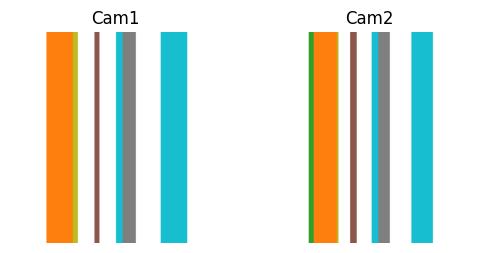

In [14]:
scene = dataset[0]
pair = scene["pairs"][0]

fig, axs = plt.subplots(1, 2, figsize=(6, 3))

axs[0].imshow(pair["image1"])
axs[0].set_title("Cam1")
axs[0].axis("off")

axs[1].imshow(pair["image2"])
axs[1].set_title("Cam2")
axs[1].axis("off")

plt.show()

In [15]:
import os
import json
import numpy as np
import imageio

DATASET_DIR = "dataset"
os.makedirs(DATASET_DIR, exist_ok=True)


def camera_to_dict(cam, f=1.0):
    R = np.stack([cam.right, cam.up, cam.dir], axis=0)
    t = -R @ cam.c

    K = np.array([
        [f, 0, 0],
        [0, f, 0],
        [0, 0, 1]
    ])

    return {
        "position": cam.c.tolist(),
        "R": R.tolist(),
        "t": t.tolist(),
        "K": K.tolist()
    }


# -----------------------
# Spara dataset
# -----------------------
for scene_idx, scene in enumerate(dataset):

    scene_dir = os.path.join(DATASET_DIR, f"scene_{scene_idx:03d}")
    img_dir = os.path.join(scene_dir, "images")

    os.makedirs(img_dir, exist_ok=True)

    cylinders = scene["cylinders"]

    scene_json = {
        "scene_id": scene_idx,
        "cylinders": [
            {"x": float(x), "y": float(y), "r": float(r), "h": float(h)}
            for (x, y, _, r, h) in cylinders
        ],
        "pairs": []
    }

    for pair_idx, pair in enumerate(scene["pairs"]):

        fname_base = f"pair_{pair_idx:03d}"

        img1_path = os.path.join(img_dir, fname_base + "_cam1.png")
        img2_path = os.path.join(img_dir, fname_base + "_cam2.png")

        # spara bilder
        imageio.imwrite(img1_path, pair["image1"])
        imageio.imwrite(img2_path, pair["image2"])

        pair_entry = {
            "pair_id": pair_idx,
            "image1": img1_path,
            "image2": img2_path,

            "vision1": pair["vision1"].tolist(),
            "vision2": pair["vision2"].tolist(),

            "camera1": camera_to_dict(pair["cam1"]),
            "camera2": camera_to_dict(pair["cam2"])
        }

        scene_json["pairs"].append(pair_entry)

    # spara JSON per scen
    label_path = os.path.join(scene_dir, "labels.json")

    with open(label_path, "w") as f:
        json.dump(scene_json, f, indent=2)

print("Dataset sparat i:", DATASET_DIR)

Dataset sparat i: dataset
